# Model Exploration and Testing

## Step 1: Data Load

In [51]:
import pandas as pd
import os

def reduce_twitter_dataset(input_file, output_file, sample_size=50000):
    """
    Reduces the Sentiment140 dataset while maintaining class balance.
    Columns: 0: target, 1: id, 2: date, 3: flag, 4: user, 5: text
    """

    if os.path.exists(output_file):
        print(f"Data already processed and saved at {output_file}")
        return

    cols = ["sentiment", "id", "date", "query", "user", "text"]

    print("Reading dataset in chunks...")
    # Using 'latin-1' encoding as this dataset often has special characters
    chunks = pd.read_csv(input_file, encoding='latin-1', header=None, names=cols, chunksize=100000)

    df_list = []
    for chunk in chunks:
        # Keep only necessary columns to save memory immediately
        df_list.append(chunk[['sentiment', 'text']])

    full_df = pd.concat(df_list)

    # Stratified sampling: Ensure 50/50 split of Positive (4) and Negative (0)
    # The dataset uses 0=negative, 2=neutral (rare), 4=positive
    negative_tweets = full_df[full_df['sentiment'] == 0].sample(n=sample_size//2, random_state=42)
    positive_tweets = full_df[full_df['sentiment'] == 4].sample(n=sample_size//2, random_state=42)

    reduced_df = pd.concat([negative_tweets, positive_tweets]).sample(frac=1).reset_index(drop=True)

    reduced_df.to_csv(output_file, index=False)
    print(f"Success! Reduced file saved to {output_file} with {len(reduced_df)} rows.")

In [52]:
init_data_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/twitter_data.csv"
reduced_data_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/reduced_twitter_data.csv"

In [53]:
reduce_twitter_dataset(init_data_path,reduced_data_path)

Data already processed and saved at /home/water/Grad School/DSE6212/Project/data/reduced_twitter_data.csv


In [54]:
df = pd.read_csv(reduced_data_path)

## Step 2: Preprocessing

In [55]:
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import re
import emoji

nltk.download("stopwords")
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /home/water/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/water/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/water/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [56]:
def preprocess(text:str, stemmer:PorterStemmer|SnowballStemmer|None=None, lem:WordNetLemmatizer|None=None):
    assert not (stemmer is not None and lem is not None)

    # Lowercase
    text = text.lower()
    #convert emojis
    text = emoji.demojize(text, delimiters=("",""), language='alias')
    # Remove handles
    text = re.sub(r'\B@\S+','',text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stop words
    tokens = [token for token in tokens if token not in set(stopwords.words('english'))]

    # Stemming
    if stemmer:
        tokens = [stemmer.stem(token) for token in tokens]
    elif lem:
        tokens = [lem.lemmatize(token) for token in tokens]

    return " ".join(tokens)

### Step 3: Vectorization

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

#### TF-IDF

In [58]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform([preprocess(text, lem=WordNetLemmatizer()) for text in df["text"].values])

print("\nTF-IDF Shape:", tfidf_matrix.shape)


TF-IDF Shape: (50000, 5000)


In [59]:
import numpy as np

In [60]:
# negative = 0, positive = 1
df['senitment'] = df['sentiment'].replace(4,1)

y = np.array(df['senitment'])
y

array([0, 0, 0, ..., 0, 1, 1], shape=(50000,))

### Step 4: Model Training

In [61]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [62]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split([preprocess(text, lem=WordNetLemmatizer()) for text in df["text"].values], y, test_size=0.3, random_state=42)

#### TF-IDF

In [63]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw)

In [64]:
svm_classifier_tfidf = LinearSVC(dual=False, max_iter=10000, random_state=42)
fit_svm_classifier_tfidf = svm_classifier_tfidf.fit(X_train_tfidf, y_train)

In [65]:
y_pred_tfidf = svm_classifier_tfidf.predict(X_test_tfidf)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(f"Model Accuracy: {accuracy_tfidf * 100:.2f}%")

Model Accuracy: 74.05%


In [66]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

class ModelEvaluator():
    def __init__(self, fit_model=None, pipe=None):
        self.model = fit_model
        self.pipe = pipe
    
    def eval_model(self, X_test, y_test, labels):
        assert self.model is not None
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.model.predict(X_test)

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred >= 0.5:
                self.reclassified_predictions.append(1)
            else:
                self.reclassified_predictions.append(0)

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def eval_pipe(self, X_test:list[str], y_test:list[int], labels):
        assert self.pipe is not None
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.pipe(X_test)

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred['label']=='LABEL_0':
                self.reclassified_predictions.append(0)
            else:
                self.reclassified_predictions.append(1)
    
        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_metrics(self):
        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(self.novel_y, self.reclassified_predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(self.novel_y, self.reclassified_predictions)

        self.accuracy = f'{accuracy_score(self.novel_y, self.reclassified_predictions)*100:.2f}%'

        # Compute recall
        self.recall = self.confusion_matrix['true_positive'] / (self.confusion_matrix['true_positive'] + self.confusion_matrix['false_negative'])

        # Compute precision
        self.precision = precision_score(self.novel_y, self.reclassified_predictions)

        # Compute F1-Score
        self.f1_score = f'{(2*self.precision*self.recall)/(self.precision+self.recall):.2f}'

        print(f'\nAccuracy: {self.accuracy}')
        print(f'\nRecall: {self.recall}')
        print(f'\nPrecision: {self.precision}')
        print(f'\nF1-Score: {self.f1_score}')

#### TF-IDF Evaluation

Number of positive Predictions: 7656
Number of negative Predictions: 7344
Percent positive Predictions: 51.04
Percent negative Predictions: 48.96

Accuracy: 74.05%

Recall: 0.749271523178808

Precision: 0.7388975966562173

F1-Score: 0.74


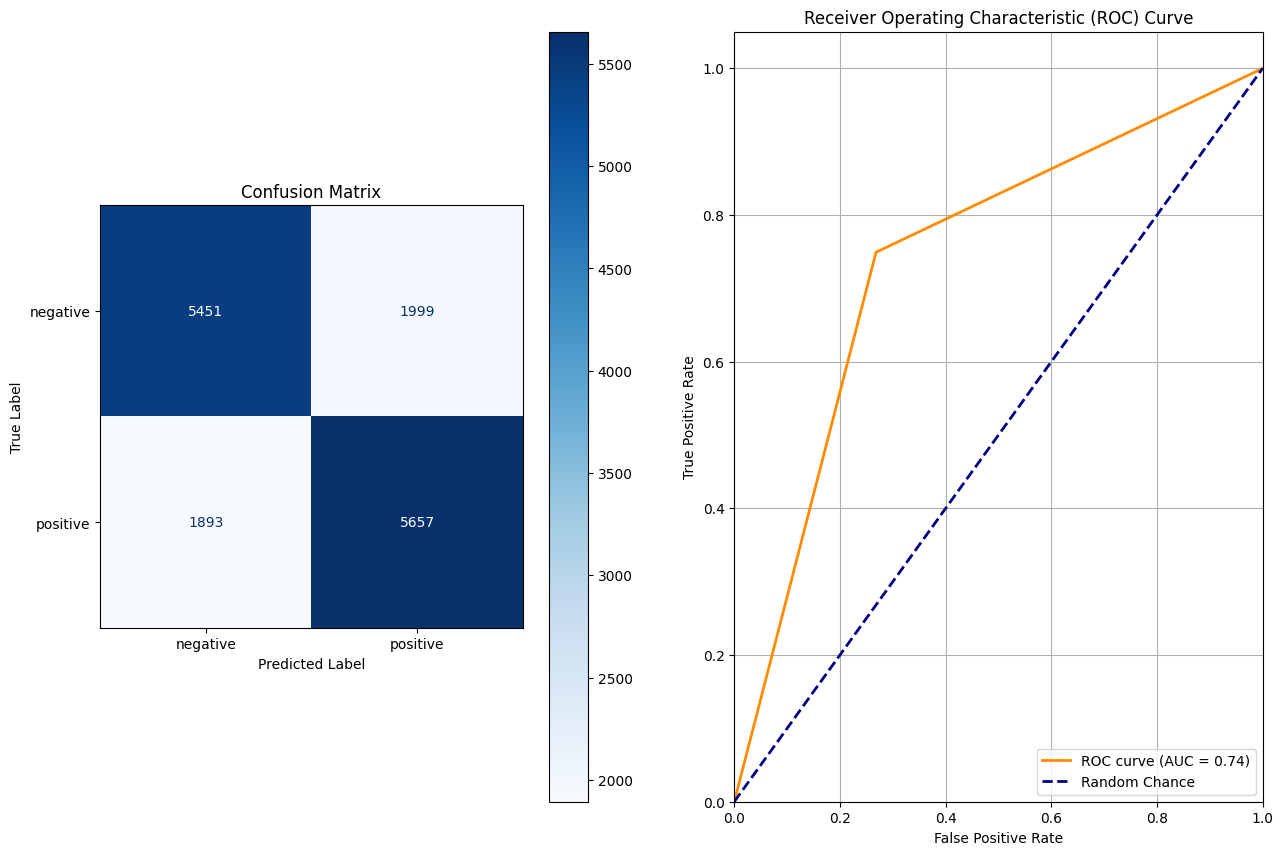

In [67]:
labels = ['negative', 'positive']

tfidf_evaluator = ModelEvaluator(fit_svm_classifier_tfidf)
tfidf_evaluator.eval_model(X_test_tfidf, y_test, labels)

### Step 5: Advanced Model Training

First, train base model with frozen attention layers.

In [68]:
from transformers import TrainingArguments, DataCollatorWithPadding, Trainer, AutoTokenizer, BertForSequenceClassification
import torch
class ModelTrainer():
    def __init__(self, checkpoint, dataset, input_max_len, epochs, freeze_transformer=False) -> None:
        self.input_max_len = input_max_len
        self.checkpoint = checkpoint
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(self.checkpoint)
        self.model = BertForSequenceClassification.from_pretrained(self.checkpoint)
        self.epochs = epochs
        self.freeze_transformer = freeze_transformer

    def _preprocess_function(self, examples):
        # Category A Blanks: Define truncation and padding strategies
        model_inputs = self.tokenizer(examples["Text"],
                                max_length=self.input_max_len, # Choose 512 for articles
                                truncation=True,)

        # We use a list comprehension to iterate through the batch of labels
        model_inputs["labels"] = examples["Sentiment"]

        return model_inputs

    def train(self):
        train_data = self.dataset['train'].map(self._preprocess_function, batched=True)
        test_data = self.dataset['test'].map(self._preprocess_function, batched=True)

        if self.freeze_transformer:
            for param in self.model.bert.parameters():
                param.requires_grad = False

        counter = 0
        while 1:
            if os.path.exists(f"./results_frozen_{self.freeze_transformer}_epochs_{self.epochs}_{counter}"):
                counter+=1
            else:
                output_dir = f"./results_frozen_{self.freeze_transformer}_epochs_{self.epochs}_{counter}"
                break

        training_args = TrainingArguments(
            output_dir=output_dir,
            learning_rate=5e-5,        # Hint: 5e-5 is standard for BART
            num_train_epochs=self.epochs,     # Hint: 3 to 5 is sufficient
            per_device_train_batch_size=8,
            fp16=torch.cuda.is_available(),
        )

        data_collator = DataCollatorWithPadding(
            tokenizer=self.tokenizer,
            padding="longest",
            max_length=self.input_max_len
        )

        # Category B Scaffold: Initialization of the Trainer API
        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_data,
            eval_dataset=test_data,
            data_collator=data_collator
        )

        # Train the model
        trainer.train()

In [69]:
import json

def save_bert_data(df, train_path, test_path):
    # Store the data in separate text files to be read in by the datasets package
    X_train_raw, X_test_raw, y_train, y_test = train_test_split([text for text in df["text"].values], y, test_size=0.3, random_state=42)

    train_data = {"type": "train",
                "data":[]
                }

    test_data = {
                "type": "test",
                "data":[]
                }

    for i in range(len(X_train_raw)):
        train_data["data"].append(
            {
                "Text":X_train_raw[i],
                "Sentiment":int(y_train[i])
        })

    for i in range(len(X_test_raw)):
        test_data["data"].append(
            {
                "Text":X_test_raw[i],
                "Sentiment":int(y_test[i])
        })

    # Save Data
    with open(train_path, 'w+') as f:
        json.dump(train_data, f)

    with open(test_path, 'w+') as f:
        json.dump(test_data, f)

In [70]:
from datasets import load_dataset

train_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/train.json"
test_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/test.json"

save_bert_data(df, train_path, test_path)

# Load from CSV
dataset = load_dataset("json", data_files={"train": train_path, "test": test_path}, field="data")


Generating train split: 35000 examples [00:00, 560489.62 examples/s]
Generating test split: 15000 examples [00:00, 709792.19 examples/s]


First, train the model with the bert architecture frozen, just training the classifier.

In [71]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

ft_base_model_frozen = ModelTrainer(base_model_checkpoint, dataset, 512, 3, freeze_transformer=True)
ft_base_model_frozen.train()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 840.22it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSI

Step,Training Loss
500,0.692281
1000,0.682346
1500,0.675933
2000,0.667225
2500,0.662122
3000,0.659907
3500,0.653924
4000,0.649567
4500,0.649522
5000,0.649389


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.04it/s]


Next, experiment with fine tuning the entire model since I have the compute for it.

In [72]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

ft_base_model_full = ModelTrainer(base_model_checkpoint, dataset, 512, 3)
ft_base_model_full.train()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 754.14it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSI

Step,Training Loss
500,0.567078
1000,0.491254
1500,0.495506
2000,0.482986
2500,0.471520
3000,0.457531
3500,0.450806
4000,0.445551
4500,0.406968
5000,0.352906


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.57it/s]


### Testing Fine-Tuned Models

In [73]:
# Load novel data
def get_novel_data(input_file, sample_size=10000):
    """
    Reduces the Sentiment140 dataset while maintaining class balance.
    Columns: 0: target, 1: id, 2: date, 3: flag, 4: user, 5: text
    """

    cols = ["sentiment", "id", "date", "query", "user", "text"]

    print("Reading dataset in chunks...")
    # Using 'latin-1' encoding as this dataset often has special characters
    chunks = pd.read_csv(input_file, encoding='latin-1', header=None, names=cols, chunksize=100000)

    df_list = []
    for chunk in chunks:
        # Keep only necessary columns to save memory immediately
        df_list.append(chunk[['sentiment', 'text']])

    full_df = pd.concat(df_list)

    # Stratified sampling: Ensure 50/50 split of Positive (4) and Negative (0)
    # The dataset uses 0=negative, 2=neutral (rare), 4=positive
    negative_tweets = full_df[full_df['sentiment'] == 0].sample(n=sample_size//2, random_state=85)
    positive_tweets = full_df[full_df['sentiment'] == 4].sample(n=sample_size//2, random_state=85)

    reduced_df = pd.concat([negative_tweets, positive_tweets]).sample(frac=1).reset_index(drop=True)

    train_data_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/reduced_twitter_data.csv"
    train_df = pd.read_csv(train_data_path)

    # Select only rows not in the training data
    unique_rows = reduced_df[~train_df['text'].isin(reduced_df['text'])]

    unique_rows['senitment'] = unique_rows['sentiment'].replace(4,1)

    return unique_rows

In [74]:
val_data = get_novel_data(f"{'/'.join(os.getcwd().split('/')[:-1])}/data/original_twitter_data.csv")

Reading dataset in chunks...


/tmp/ipykernel_39505/2544413536.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unique_rows = reduced_df[~train_df['text'].isin(reduced_df['text'])]


In [75]:
from transformers import pipeline

def test_model(model_checkpoint, val_data):
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
    model = BertForSequenceClassification.from_pretrained(model_checkpoint)

    #Set up the analysis pipe
    pipe = pipeline(task="sentiment-analysis", model=model, tokenizer=tokenizer)
    pipe_evaluator = ModelEvaluator(pipe=pipe)

    labels = ["Negative", "Positive"]
    X_val = list(val_data['text'].values)
    y_val = np.array(val_data['senitment'])

    pipe_evaluator.eval_pipe(X_test=X_val, y_test=y_val, labels=labels)

Test the model with frozen weights.

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 961.82it/s, Materializing param=classifier.weight]                                      


Number of Positive Predictions: 5341
Number of Negative Predictions: 4584
Percent Positive Predictions: 53.81360201511335
Percent Negative Predictions: 46.18639798488665

Accuracy: 73.55%

Recall: 0.7734595247684253

Precision: 0.7191537165324845

F1-Score: 0.75


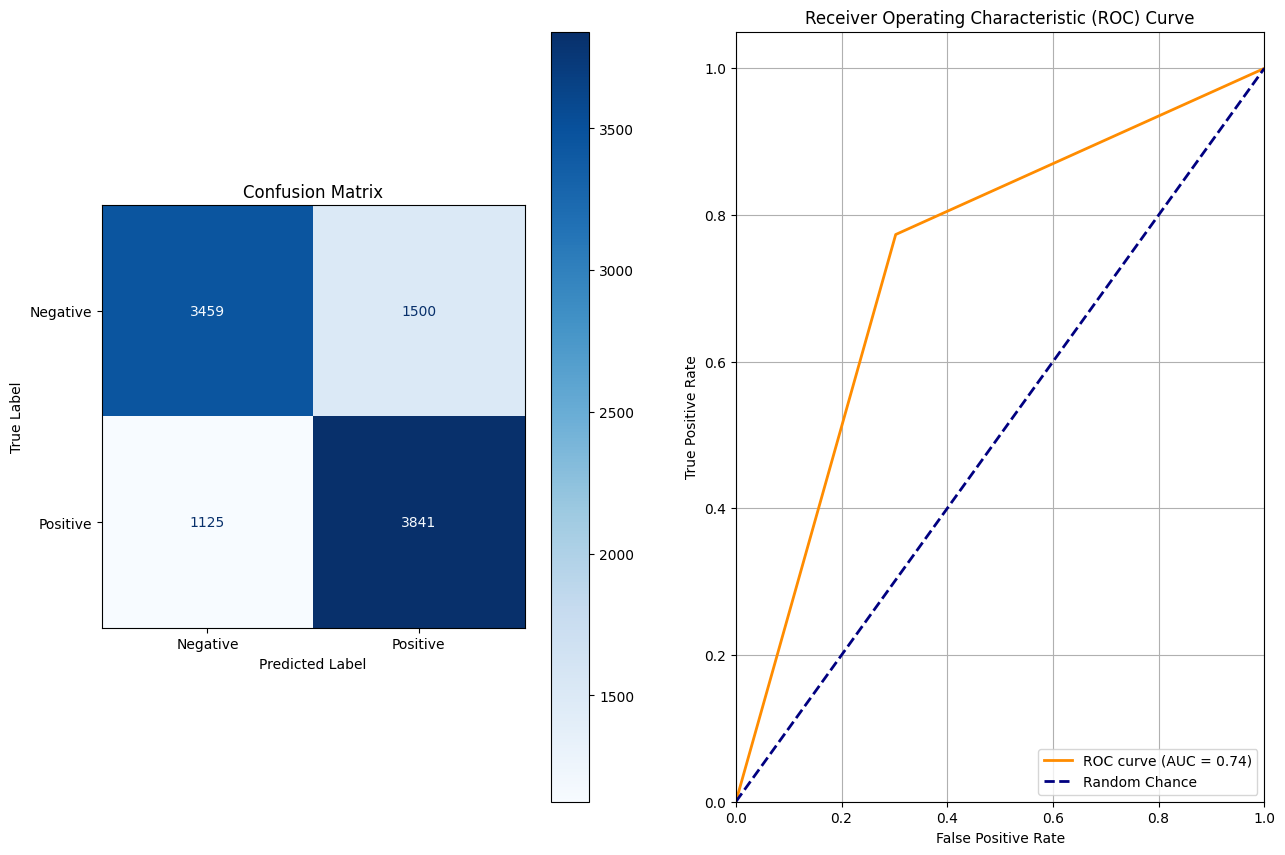

In [ ]:
frozen_weights_25_checkpoint = 'results_frozen_True_epochs_25_0/checkpoint-109000'
test_model(frozen_weights_25_checkpoint, val_data)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 966.05it/s, Materializing param=classifier.weight]                                      


Number of Positive Predictions: 4823
Number of Negative Predictions: 5102
Percent Positive Predictions: 48.594458438287155
Percent Negative Predictions: 51.405541561712845

Accuracy: 82.12%

Recall: 0.8068868304470399

Precision: 0.8308106987352271

F1-Score: 0.82


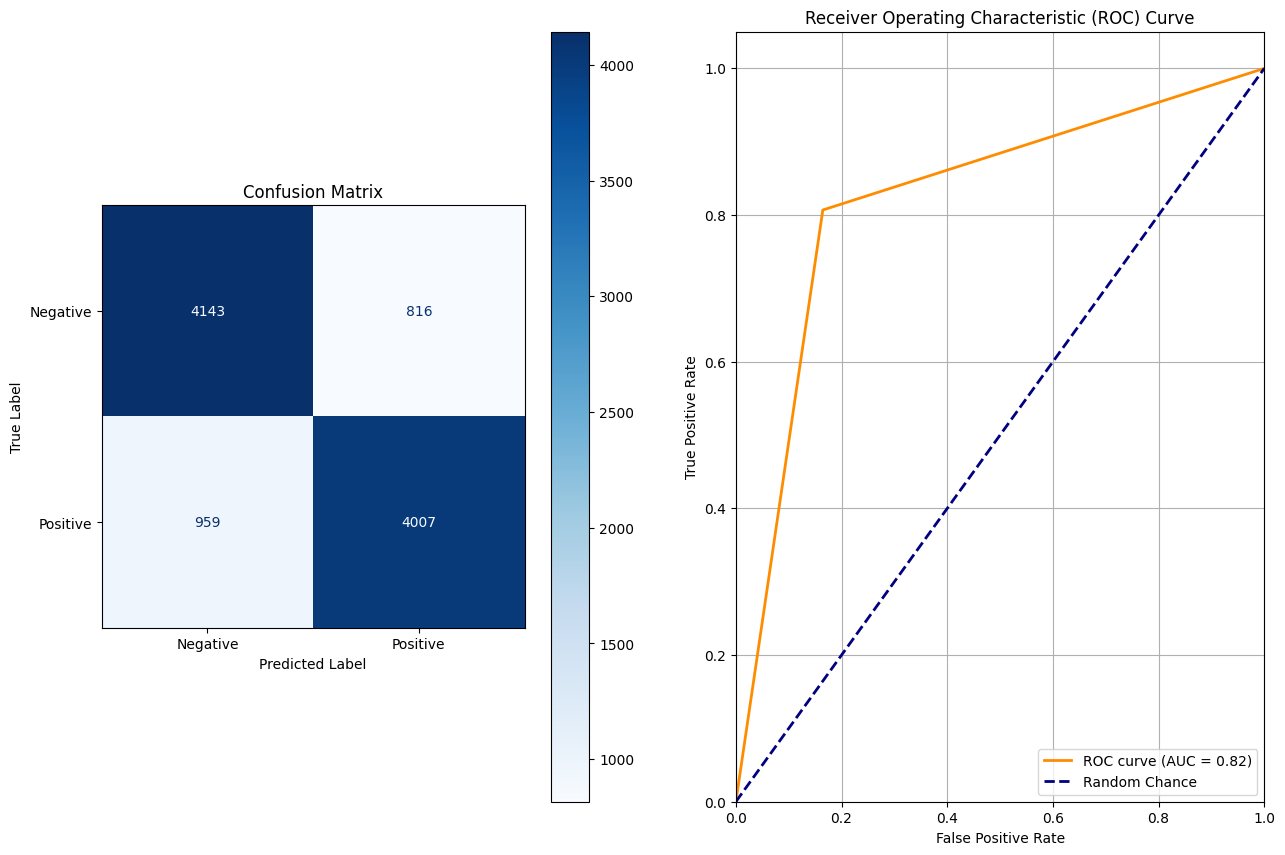

In [ ]:
full_model_5_checkpoint = 'results_frozen_False_epochs_5_0/checkpoint-21500'
test_model(full_model_5_checkpoint, val_data)

Test with lower epoch count.

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 776.77it/s, Materializing param=classifier.weight]                                      


Number of Positive Predictions: 5641
Number of Negative Predictions: 4284
Percent Positive Predictions: 56.83627204030227
Percent Negative Predictions: 43.16372795969773

Accuracy: 69.08%

Recall: 0.7589609343536046

Precision: 0.668143946108846

F1-Score: 0.71


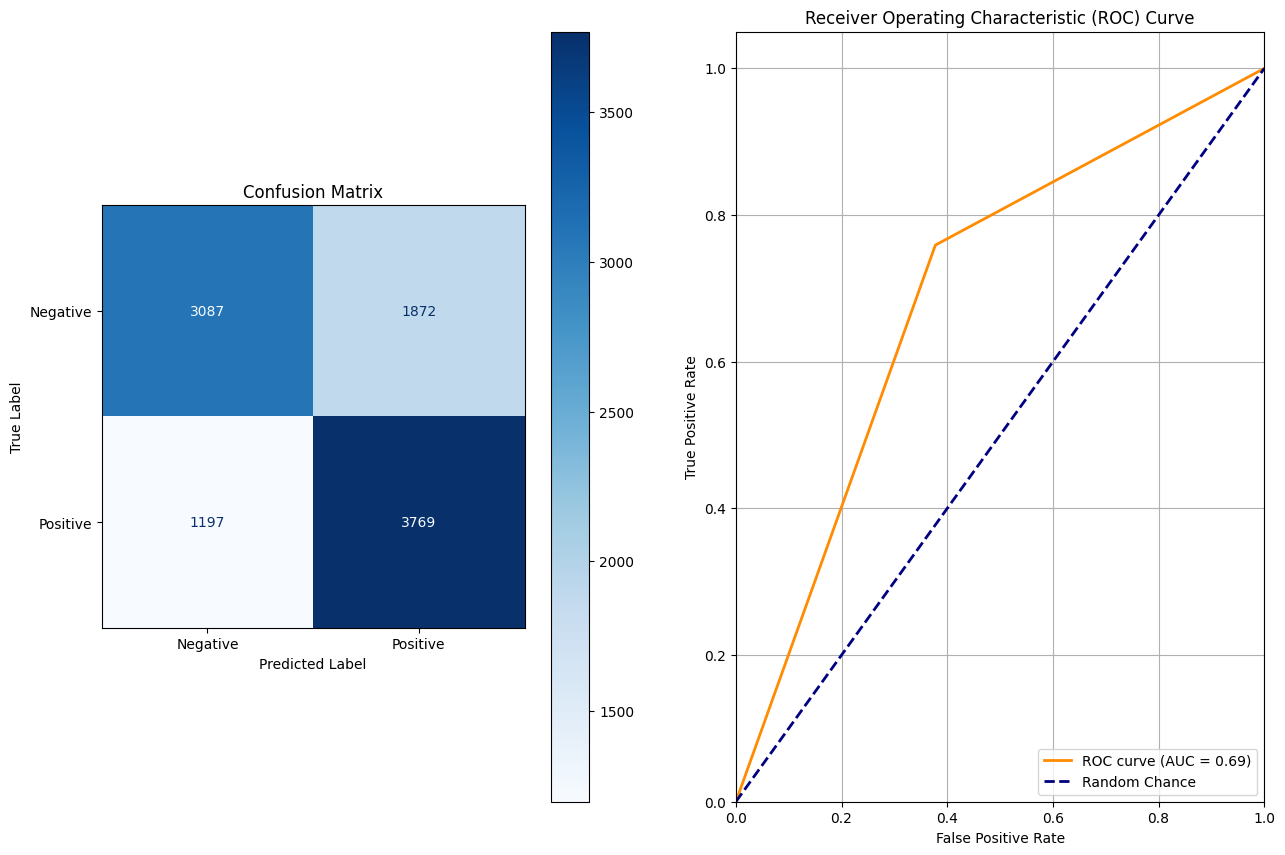

In [78]:
frozen_weights_3_checkpoint = 'results_frozen_True_epochs_3_0/checkpoint-13000'
test_model(frozen_weights_3_checkpoint, val_data)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 883.64it/s, Materializing param=classifier.weight]                                      


Number of Positive Predictions: 4934
Number of Negative Predictions: 4991
Percent Positive Predictions: 49.712846347607055
Percent Negative Predictions: 50.287153652392945

Accuracy: 83.52%

Recall: 0.8320579943616593

Precision: 0.837454398054317

F1-Score: 0.83


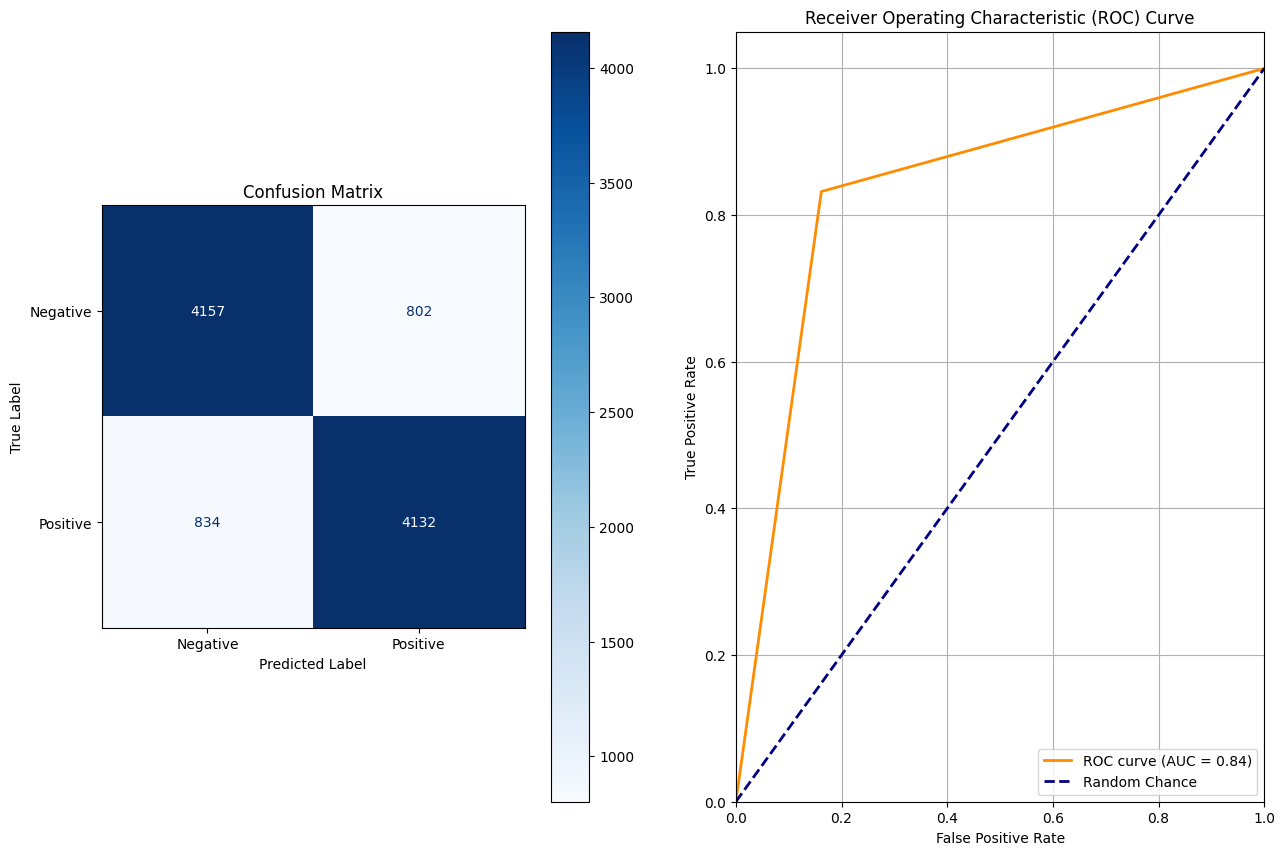

In [79]:
full_model_3_checkpoint = 'results_frozen_False_epochs_3_0/checkpoint-13000'
test_model(full_model_3_checkpoint, val_data)